# Support Vector Regression

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_absolute_percentage_error, r2_score, mean_absolute_error
# random state used = 25
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=25,
)

from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.reshape(-1, 1))
X_test_scaled = scaler.transform(X_test.reshape(-1, 1))

# defining the parameters
param_grid = {
    'C':       [1, 10, 100, 500, 700, 900, 1000],
    'epsilon': [0.001, 0.01, 0.05, 0.1, 0.5, 1, 1.5, 5, 20],
    'kernel':  ['linear', 'rbf', 'poly'],
    'gamma':   ['scale', 'auto', 0.01, 0.1, 1, 1.5, 2, 5],
}

# run grid search
svr = SVR()
grid_search = GridSearchCV(
    svr,
    param_grid,
    cv=4,
    scoring='neg_mean_absolute_error',
    verbose=3,
    n_jobs=-1,
)

grid_search.fit(X_train_scaled, y_train)

print("Best parameters:", grid_search.best_params_)

# choose best parameters to predict
model_svr = grid_search.best_estimator_
y_pred = model_svr.predict(X_test_scaled)

# MAPE and R-squared scores
mape = mean_absolute_percentage_error(y_test, y_pred) * 100
r2   = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"MAPE:      {mape:.2f}%")
print(f"R-squared: {r2:.4f}")
print(f"MAE  : {mae:.2f}")
print(len(y_test), len(y_pred))

# Linear Regression

In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

X = df_final["pixel_area"].values
y = df_final["Actual_Weight"].values
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=25,
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.reshape(-1, 1))
X_test_scaled = scaler.transform(X_test.reshape(-1, 1))

# training linear regression
reg = LinearRegression()
reg.fit(X_train_scaled, y_train)
reg.score
y_pred = reg.predict(X_test_scaled)

# MAPE and R-squared scores
mape = mean_absolute_percentage_error(y_test, y_pred) * 100
r2   = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"MAPE:      {mape:.2f}%")
print(f"R-squared: {r2:.4f}")
print(f"MAE  : {mae:.2f}")
print(len(y_test), len(y_pred))

In [ ]:
# Plot
fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(y_test, y_pred, alpha=0.6, edgecolors='darkslategray', facecolors='greenyellow', s=50)

lo = min(y_test.min(), y_pred.min())
hi = max(y_test.max(), y_pred.max())
pad = (hi - lo) * 0.08

# Best fit line
m, b = np.polyfit(y_test, y_pred, 1)

x_fit = np.array([lo - pad, hi + pad])
y_fit = m * x_fit + b

ax.plot(
    x_fit,
    y_fit,
    color='maroon',
    linewidth=1.2,
    label='Best Fit Line'
)
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)
ax.set_xlabel('Actual weight (g)')
ax.set_ylabel('Predicted weight (g)')
# ax.set_title('Linear Regression — Predicted vs Actual Weight')
ax.set_title('Linear Regression')
ax.text(0.05, 0.95, f'R² = {r2:.2f}\nMAE = {mae:.2f}\nMAPE = {mape:.2f}%',
        transform=ax.transAxes, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
ax.xaxis.set_major_locator(ticker.MultipleLocator(250))
ax.yaxis.set_major_locator(ticker.MultipleLocator(250))
ax.legend(loc='lower right')
ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# Random Forest Regressor

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.metrics import mean_absolute_percentage_error, r2_score, mean_absolute_error

# df_final = pd.read_csv("7760iter.csv")
df_final = pd.read_csv("15560iter.csv")
X = df_final["pixel_area"].values
y = df_final["Actual_Weight"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=25
)

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.reshape(-1, 1))
X_test_scaled = scaler.transform(X_test.reshape(-1, 1))

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model",  RandomForestRegressor(random_state=25, n_jobs=-1))
])

param_grid = {
    "model__n_estimators":      [35, 50, 100, 150],
    "model__max_depth":         [None, 2, 5, 10],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf":  [1, 2, 4, 6],
}
rf = RandomForestRegressor(random_state=25, n_jobs=-1)

grid_search = GridSearchCV(
    estimator  = pipeline,
    param_grid = param_grid,
    scoring    = "neg_mean_absolute_percentage_error",
    cv         = 2,
    n_jobs     = -1,
    verbose    = 1
)

# grid_search.fit(X_train.reshape(-1, 1), y_train)
grid_search.fit(X_train_scaled, y_train)


print("Best params:", grid_search.best_params_)
print("Best CV MAPE:", -grid_search.best_score_ * 100, "%")

best_rf = grid_search.best_estimator_
y_pred  = best_rf.predict(X_test_scaled)

# Metrics
r2   = r2_score(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = mean_absolute_percentage_error(y_test, y_pred) * 100

print(f"R²   : {r2:.4f}")
print(f"MAE  : {mae:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"MAPE : {mape:.2f}%")


Fitting 2 folds for each of 192 candidates, totalling 384 fits
Best params: {'model__max_depth': 5, 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 50}
Best CV MAPE: 8.68736717185291 %
R²   : 0.9725
MAE  : 63.689
RMSE : 103.418
MAPE : 6.89%


In [ ]:
# NO GRID VERSION
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=25,
    n_jobs=-1
)

rf.fit(X_train_scaled, y_train)
y_pred = rf.predict(X_test_scaled)

# performance metrics
r2   = r2_score(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = mean_absolute_percentage_error(y_test, y_pred) * 100

print(f"R²   : {r2:.4f}")
print(f"MAE  : {mae:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"MAPE : {mape:.2f}%")

R²   : 0.9706
MAE  : 59.583
RMSE : 106.878
MAPE : 6.21%


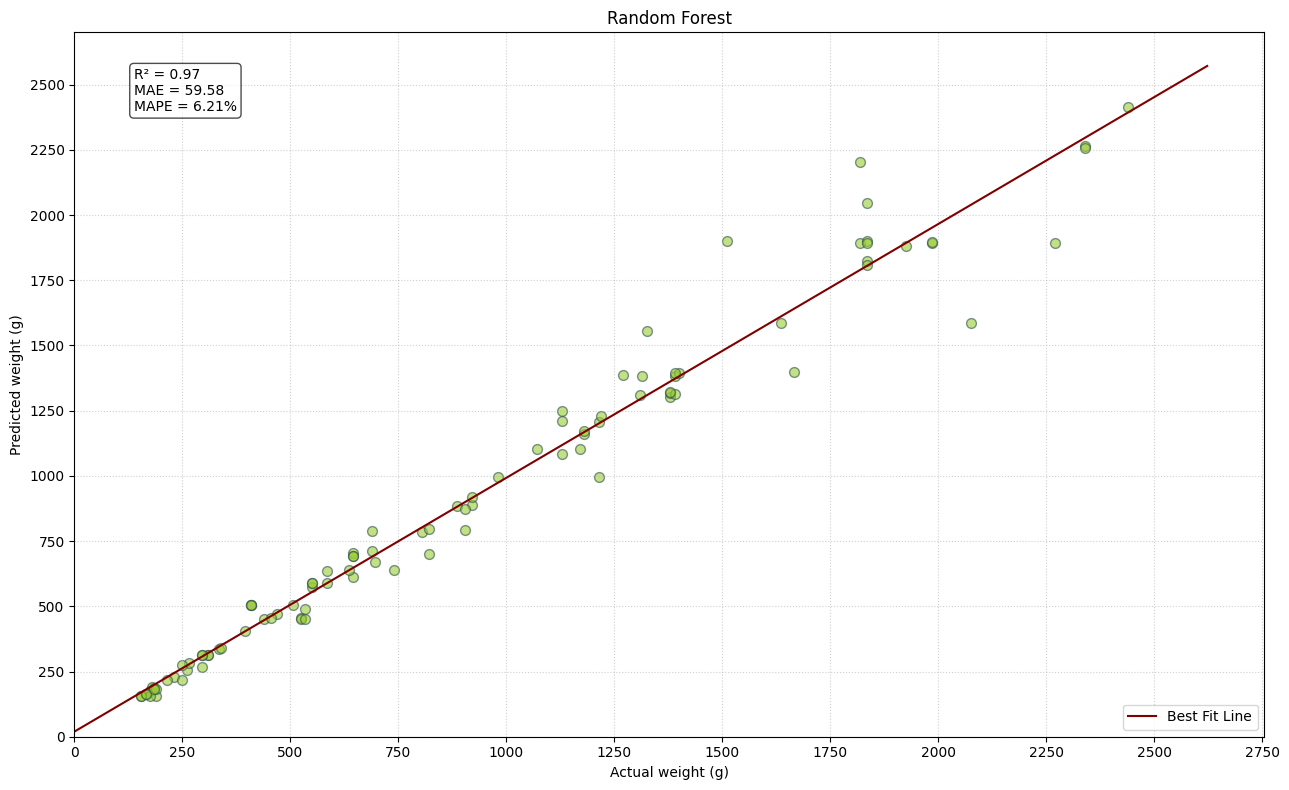

In [ ]:
# Plot
fig, ax = plt.subplots(figsize=(13, 8))
ax.scatter(y_test, y_pred, alpha=0.6, edgecolors='darkslategray', facecolors='yellowgreen', s=50)

# Axis range
lo = min(y_test.min(), y_pred.min())
hi = max(y_test.max(), y_pred.max())
pad = (hi - lo) * 0.08

# Best fit line
m, b = np.polyfit(y_test, y_pred, 1)

x_fit = np.array([lo - pad, hi + pad])
y_fit = m * x_fit + b

ax.plot(
    x_fit,
    y_fit,
    color='maroon',
    linewidth=1.5,
    label = 'Best Fit Line'
)
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)
ax.set_xlabel('Actual weight (g)')
ax.set_ylabel('Predicted weight (g)')
# ax.set_title('Random Forest — Predicted vs Actual Weight')
ax.set_title('Random Forest')
# ax.legend()
ax.grid(True, linestyle=':', alpha=0.6)
ax.text(0.05, 0.95, f'R² = {r2:.2f}\nMAE = {mae:.2f}\nMAPE = {mape:.2f}%',
        transform=ax.transAxes, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
ax.xaxis.set_major_locator(ticker.MultipleLocator(250))
ax.yaxis.set_major_locator(ticker.MultipleLocator(250))
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [ ]:
print(y_pred)
print(y_test)

[1301.5   457.05  786.75  703.4   165.5   573.85 1383.2   157.4   994.45
  451.5   610.95  313.5   885.35 1399.4  1083.7   788.75 1318.65  313.5
  312.45  635.45  191.9   589.1   691.9  1384.9  2412.7   671.    254.15
 1315.7   403.55 1102.8   489.95  713.75 1248.5   451.5   175.75  503.25
  228.6  1891.1  1208.9  1584.65  157.4   312.45  186.15 2263.9   165.5
 1825.7   452.95  887.8  1894.    503.25 1393.3   794.75  283.75 1320.
 1205.6  1310.4  1902.45  640.85  640.85 1807.4   470.25  157.4   702.25
 2256.5   157.4  1229.5  1385.9   274.9   217.4  1893.75 1880.   2044.35
  589.25 1557.3   335.35 1895.    691.9   793.1   590.4  1162.1  1900.
  456.35 1893.75 1395.2   165.    265.45  184.   1170.7   918.15  994.45
 2203.3   184.    503.25  872.25  216.8   338.4  1102.8   503.25 1584.65]
[1380  525  805  645  165  550 1390  190  980  440  645  310  885 1665
 1130  690 1380  310  295  585  180  550  645 1315 2440  695  260 1390
  395 1070  535  690 1130  525  175  505  230 2270 1130 1635

# XGB Regressor

In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

X = df_final["pixel_area"].values
y = df_final["Actual_Weight"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=25
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.reshape(-1, 1))
X_test_scaled = scaler.transform(X_test.reshape(-1, 1))

# Grid Search
param_grid = {
    "n_estimators":      [50, 100, 200],
    "max_depth":         [2, 4, 6, 10],
    "learning_rate": [0.01, 0.1, 0.5],
    "subsample":  [0.6, 0.8, 1],
    # "colsample_bytree": [0.3, 0.8],
    "booster": ['gbtree', 'dart'],
    "tree_method": ['exact', 'approx'],

}

xgb = XGBRegressor(random_state=25, n_jobs=-1)

grid_search = GridSearchCV(
    estimator  = xgb,
    param_grid = param_grid,
    scoring    = "neg_mean_absolute_percentage_error",
    cv         = 4,        # 3-fold cross validation
    n_jobs     = -1,       # use all cores
    verbose    = 1
)

grid_search.fit(X_train_scaled, y_train)
print("Best parameters:", grid_search.best_params_)

print("Best params:", grid_search.best_params_)
print("Best CV R² :", grid_search.best_score_)

# Use the best model
best_xgb = grid_search.best_estimator_
y_pred = best_xgb.predict(X_test_scaled)

# NO GRID VERSION
# xgb = XGBRegressor(
#     n_estimators=100,
#     learning_rate=0.1,
#     max_depth=6,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     random_state=25,
#     n_jobs=-1
# )

# xgb.fit(X_train_scaled, y_train,
#         eval_set=[(X_test_scaled, y_test)],
#         verbose=False)

# y_pred = xgb.predict(X_test_scaled)

# Metrics
r2   = r2_score(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = mean_absolute_percentage_error(y_test, y_pred) * 100

print(f"R²   : {r2:.4f}")
print(f"MAE  : {mae:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"MAPE : {mape:.2f}%")

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(y_test, y_pred, alpha=0.6, edgecolors='darkslategray', facecolors='yellowgreen', s=50)

# Axis range
lo = min(y_test.min(), y_pred.min())
hi = max(y_test.max(), y_pred.max())
pad = (hi - lo) * 0.08

# Best fit line
m, b = np.polyfit(y_test, y_pred, 1)

x_fit = np.array([lo - pad, hi + pad])
y_fit = m * x_fit + b

ax.plot(
    x_fit,
    y_fit,
    color='maroon',
    linewidth=1.5,
    label = 'Best Fit Line'
)
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)
ax.set_xlabel('Actual weight (g)')
ax.set_ylabel('Predicted weight (g)')
# ax.set_title('XGBoost — Predicted vs Actual Weight')
ax.set_title('XGBRegressor')
ax.text(0.05, 0.95, f'R² = {r2:.2f}\nMAE = {mae:.2f}\nMAPE = {mape:.2f}%',
        transform=ax.transAxes, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
ax.grid(True, linestyle=':', alpha=0.6)
ax.xaxis.set_major_locator(ticker.MultipleLocator(250))
ax.yaxis.set_major_locator(ticker.MultipleLocator(250))
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Polynomial Regression

Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best degree: 5
Best CV MAPE: 8.994489791476228 %
R²   : 0.9602
MAE  : 76.489
RMSE : 124.365
MAPE : 8.39%


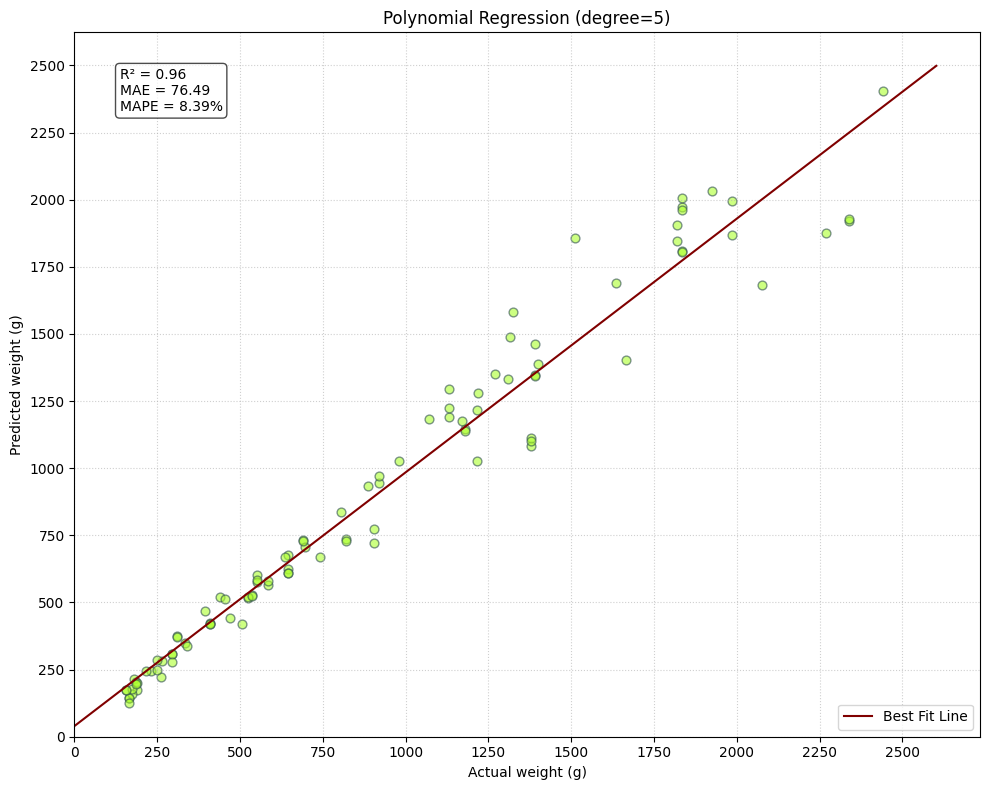

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("poly",   PolynomialFeatures(include_bias=False)),
    ("model",  LinearRegression())
])

param_grid = {
    "poly__degree": [2, 3, 4, 5],
}

grid_search = GridSearchCV(
    estimator  = pipeline,
    param_grid = param_grid,
    scoring    = "neg_mean_absolute_percentage_error",
    cv         = 3,
    n_jobs     = -1,
    verbose    = 1
)

grid_search.fit(X_train.reshape(-1, 1), y_train)

print("Best degree:", grid_search.best_params_["poly__degree"])
print("Best CV MAPE:", -grid_search.best_score_ * 100, "%")

best_model = grid_search.best_estimator_
y_pred     = best_model.predict(X_test.reshape(-1, 1))

# Metrics
r2   = r2_score(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = mean_absolute_percentage_error(y_test, y_pred) * 100

print(f"R²   : {r2:.4f}")
print(f"MAE  : {mae:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"MAPE : {mape:.2f}%")

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(y_test, y_pred, alpha=0.6, edgecolors='darkslategray', facecolors='greenyellow', s=40)

lo  = min(y_test.min(), y_pred.min())
hi  = max(y_test.max(), y_pred.max())
pad = (hi - lo) * 0.07

m, b  = np.polyfit(y_test, y_pred, 1)
x_fit = np.array([lo - pad, hi + pad])
y_fit = m * x_fit + b

ax.plot(x_fit, y_fit, color='maroon', linewidth=1.5, label='Best Fit Line')
ax.set_xlabel('Actual weight (g)')
ax.set_ylabel('Predicted weight (g)')
ax.set_title(f'Polynomial Regression (degree={grid_search.best_params_["poly__degree"]})')
ax.xaxis.set_major_locator(ticker.MultipleLocator(250))
ax.yaxis.set_major_locator(ticker.MultipleLocator(250))
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)
ax.legend(loc='lower right')
ax.text(0.05, 0.95, f'R² = {r2:.2f}\nMAE = {mae:.2f}\nMAPE = {mape:.2f}%',
        transform=ax.transAxes, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
ax.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

# Ridge Regression

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Best params: {'model__alpha': 1}
Best CV MAPE: 9.275111021457775 %
R²          : 0.9595
MAE         : 76.786
RMSE        : 125.426
MAPE        : 8.70%


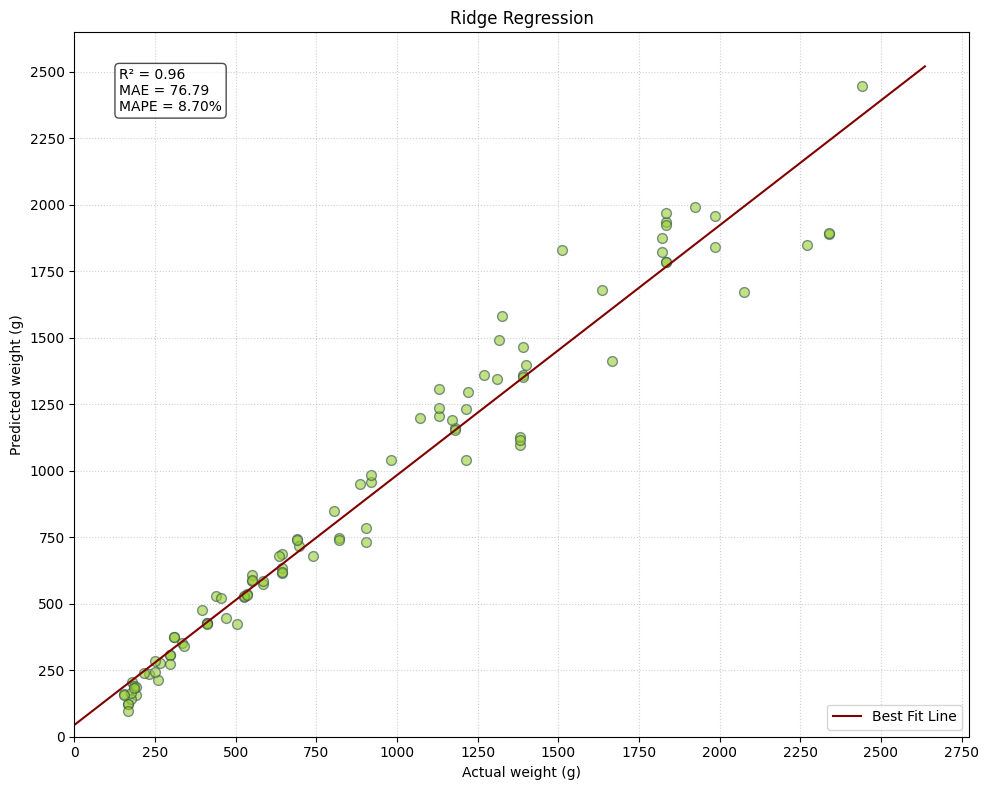

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# X = df_final["pixel_area"].values
# y = df_final["Actual_Weight"].values

# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.3, random_state=25
# )

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model",  Ridge())
])

param_grid = {
    "model__alpha": [0.001, 0.01, 0.1, 1, 10, 100, 1000],
}

grid_search = GridSearchCV(
    estimator  = pipeline,
    param_grid = param_grid,
    scoring    = "neg_mean_absolute_percentage_error",
    cv         = 5,
    n_jobs     = -1,
    verbose    = 1
)

grid_search.fit(X_train.reshape(-1, 1), y_train)

print("Best params:", grid_search.best_params_)
print("Best CV MAPE:", -grid_search.best_score_ * 100, "%")

best_ridge = grid_search.best_estimator_
y_pred     = best_ridge.predict(X_test.reshape(-1, 1))

# extract the actual Ridge model from the pipeline
ridge_model = best_ridge.named_steps["model"]

# Metrics
r2   = r2_score(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = mean_absolute_percentage_error(y_test, y_pred) * 100

print(f"R²          : {r2:.4f}")
print(f"MAE         : {mae:.3f}")
print(f"RMSE        : {rmse:.3f}")
print(f"MAPE        : {mape:.2f}%")

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(y_test, y_pred, alpha=0.6, edgecolors='darkslategray', facecolors='yellowgreen', s=50)

lo  = min(y_test.min(), y_pred.min())
hi  = max(y_test.max(), y_pred.max())
pad = (hi - lo) * 0.08

m, b  = np.polyfit(y_test, y_pred, 1)
x_fit = np.array([lo - pad, hi + pad])
y_fit = m * x_fit + b

ax.plot(x_fit, y_fit, color='maroon', linewidth=1.5, label='Best Fit Line')
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)
ax.set_xlabel('Actual weight (g)')
ax.set_ylabel('Predicted weight (g)')
ax.set_title('Ridge Regression')
ax.text(0.05, 0.95, f'R² = {r2:.2f}\nMAE = {mae:.2f}\nMAPE = {mape:.2f}%',
        transform=ax.transAxes, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
ax.grid(True, linestyle=':', alpha=0.6)
ax.xaxis.set_major_locator(ticker.MultipleLocator(250))
ax.yaxis.set_major_locator(ticker.MultipleLocator(250))
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Lasso Regression

In [ ]:
from sklearn.linear_model import Lasso, LassoCV
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
X = df_final["pixel_area"].values
y = df_final["Actual_Weight"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=25
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.reshape(-1, 1))
X_test_scaled = scaler.transform(X_test.reshape(-1, 1))

lasso = Lasso(
    alpha=1.0,          # regularization strength, higher = more shrinkage
    max_iter=1000,
    random_state=25
)

lasso.fit(X_train_scaled, y_train)
y_pred = lasso.predict(X_test_scaled)

# Metrics
r2   = r2_score(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = mean_absolute_percentage_error(y_test, y_pred) * 100

print(f"R²   : {r2:.4f}")
print(f"MAE  : {mae:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"MAPE : {mape:.2f}%")
print(f"Coefficient : {lasso.coef_[0]:.4f}")
print(f"Intercept   : {lasso.intercept_:.4f}")

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(y_test, y_pred, alpha=0.6, edgecolors='darkslategray', facecolors='yellowgreen', s=40)

# Axis range
lo = min(y_test.min(), y_pred.min())
hi = max(y_test.max(), y_pred.max())
pad = (hi - lo) * 0.06
# ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], 'r--', linewidth=1.5, label='Perfect fit')

# Best fit line
m, b = np.polyfit(y_test, y_pred, 1)

x_fit = np.array([lo - pad, hi + pad])
y_fit = m * x_fit + b

ax.plot(
    x_fit,
    y_fit,
    color='maroon',
    linewidth=1.5,
    label='Best Fit Line'
)
ax.set_xlim(0, hi + pad)
ax.set_ylim(0, hi + pad)
ax.set_xlabel('Actual weight (g)')
ax.set_ylabel('Predicted weight (g)')
ax.set_title('Lasso Regression')
ax.xaxis.set_major_locator(ticker.MultipleLocator(250))
ax.yaxis.set_major_locator(ticker.MultipleLocator(250))
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)
ax.legend(loc='lower right')
ax.text(0.05, 0.95, f'R² = {r2:.2f}\nMAE = {mae:.2f}\nMAPE = {mape:.2f}%',
        transform=ax.transAxes, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
ax.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

# Bayesian Linear

Fitting 5 folds for each of 144 candidates, totalling 720 fits
Best params: {'model__alpha_init': 0.1, 'model__lambda_init': 0.1, 'model__max_iter': 100, 'model__tol': 0.01}
Best CV MAPE: 9.31461074571948 %
R²   : 0.9597
MAE  : 76.899
RMSE : 125.192
MAPE : 8.72%


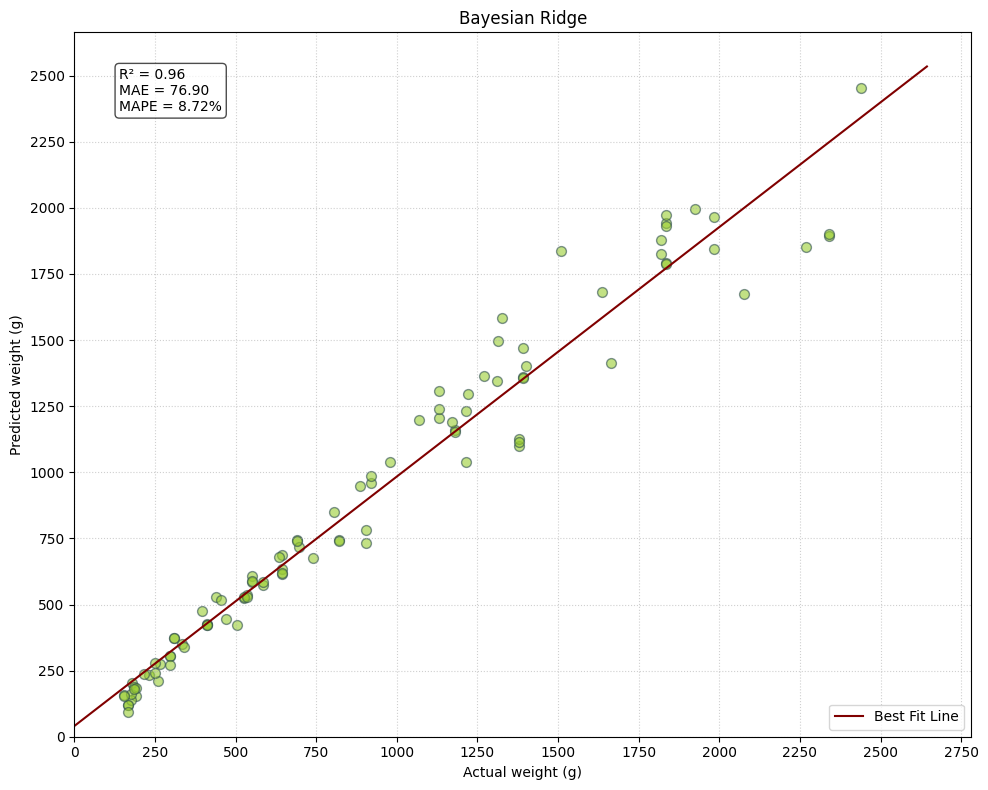

In [ ]:
from sklearn.linear_model import BayesianRidge
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# X = df_final["pixel_area"].values
# y = df_final["Actual_Weight"].values

# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.3, random_state=25
# )

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model",  BayesianRidge(compute_score=True))
])

param_grid = {
    "model__max_iter":   [100, 300, 500],
    "model__tol":        [1e-2, 1e-3, 1e-4],
    "model__alpha_init": [None, 0.1, 1.0, 10.0],  # initial precision of weights
    "model__lambda_init":[None, 0.1, 1.0, 10.0],  # initial precision of noise
}

grid_search = GridSearchCV(
    estimator  = pipeline,
    param_grid = param_grid,
    scoring    = "neg_mean_absolute_percentage_error",
    cv         = 5,
    n_jobs     = -1,
    verbose    = 1
)

grid_search.fit(X_train.reshape(-1, 1), y_train)

print("Best params:", grid_search.best_params_)
print("Best CV MAPE:", -grid_search.best_score_ * 100, "%")

best_bayes = grid_search.best_estimator_

# predict with uncertainty intervals — reach inside pipeline for return_std
bayes_model = best_bayes.named_steps["model"]
X_test_transformed = best_bayes.named_steps["scaler"].transform(X_test.reshape(-1, 1))
y_pred, y_std = bayes_model.predict(X_test_transformed, return_std=True)

# Metrics
r2   = r2_score(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = mean_absolute_percentage_error(y_test, y_pred) * 100

print(f"R²   : {r2:.4f}")
print(f"MAE  : {mae:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"MAPE : {mape:.2f}%")

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(y_test, y_pred, alpha=0.6, edgecolors='darkslategray', facecolors='yellowgreen', s=50)

lo  = min(y_test.min(), y_pred.min())
hi  = max(y_test.max(), y_pred.max())
pad = (hi - lo) * 0.08

m, b  = np.polyfit(y_test, y_pred, 1)
x_fit = np.array([lo - pad, hi + pad])
y_fit = m * x_fit + b

ax.plot(x_fit, y_fit, color='maroon', linewidth=1.5, label='Best Fit Line')
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)
ax.set_xlabel('Actual weight (g)')
ax.set_ylabel('Predicted weight (g)')
ax.set_title('Bayesian Ridge')
ax.xaxis.set_major_locator(ticker.MultipleLocator(250))
ax.yaxis.set_major_locator(ticker.MultipleLocator(250))
ax.legend(loc='lower right')
ax.text(0.05, 0.95, f'R² = {r2:.2f}\nMAE = {mae:.2f}\nMAPE = {mape:.2f}%',
        transform=ax.transAxes, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
ax.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

# ElasticNet

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best params: {'model__alpha': 0.1, 'model__l1_ratio': 0.9}
Best CV MAPE: 9.260611267351473 %
R²          : 0.9593
MAE         : 76.918
RMSE        : 125.821
MAPE        : 8.76%
Coefficient : 604.2416
Intercept   : 919.4956


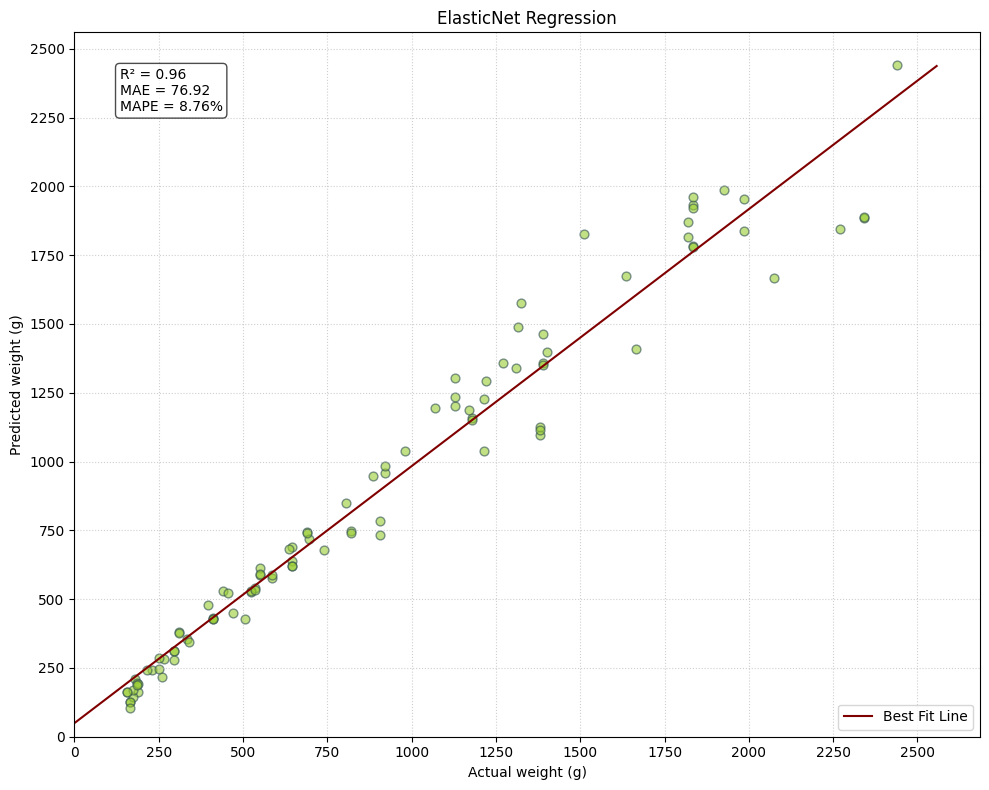

In [ ]:
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# X = df_final["pixel_area"].values
# y = df_final["Actual_Weight"].values

# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.3, random_state=25
# )

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model",  ElasticNet(max_iter=1000, random_state=25))
])

param_grid = {
    "model__alpha":    [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
    "model__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9, 1.0],
    #                   ↑ 0=pure Ridge, 1=pure Lasso, in between=ElasticNet
}

grid_search = GridSearchCV(
    estimator  = pipeline,
    param_grid = param_grid,
    scoring    = "neg_mean_absolute_percentage_error",
    cv         = 5,
    n_jobs     = -1,
    verbose    = 1
)

grid_search.fit(X_train.reshape(-1, 1), y_train)

print("Best params:", grid_search.best_params_)
print("Best CV MAPE:", -grid_search.best_score_ * 100, "%")

best_en    = grid_search.best_estimator_
y_pred     = best_en.predict(X_test.reshape(-1, 1))
en_model   = best_en.named_steps["model"]

# Metrics
r2   = r2_score(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = mean_absolute_percentage_error(y_test, y_pred) * 100

print(f"R²          : {r2:.4f}")
print(f"MAE         : {mae:.3f}")
print(f"RMSE        : {rmse:.3f}")
print(f"MAPE        : {mape:.2f}%")
print(f"Coefficient : {en_model.coef_[0]:.4f}")
print(f"Intercept   : {en_model.intercept_:.4f}")

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(y_test, y_pred, alpha=0.6, edgecolors='darkslategray', facecolors='yellowgreen', s=40)

lo  = min(y_test.min(), y_pred.min())
hi  = max(y_test.max(), y_pred.max())
pad = (hi - lo) * 0.05

m, b  = np.polyfit(y_test, y_pred, 1)
x_fit = np.array([lo - pad, hi + pad])
y_fit = m * x_fit + b

ax.plot(x_fit, y_fit, color='maroon', linewidth=1.5, label='Best Fit Line')
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)
ax.set_xlabel('Actual weight (g)')
ax.set_ylabel('Predicted weight (g)')
ax.set_title('ElasticNet Regression')
ax.xaxis.set_major_locator(ticker.MultipleLocator(250))
ax.yaxis.set_major_locator(ticker.MultipleLocator(250))
ax.legend(loc='lower right')
ax.text(0.05, 0.95, f'R² = {r2:.2f}\nMAE = {mae:.2f}\nMAPE = {mape:.2f}%',
        transform=ax.transAxes, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
ax.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

# MLP Regressor

Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best params: {'model__activation': 'tanh', 'model__hidden_layer_sizes': (64,), 'model__learning_rate_init': 0.001, 'model__solver': 'sgd'}
Best CV MAPE: 8.682565199906353 %
R²   : 0.9455
MAE  : 97.514
RMSE : 145.543
MAPE : 11.26%


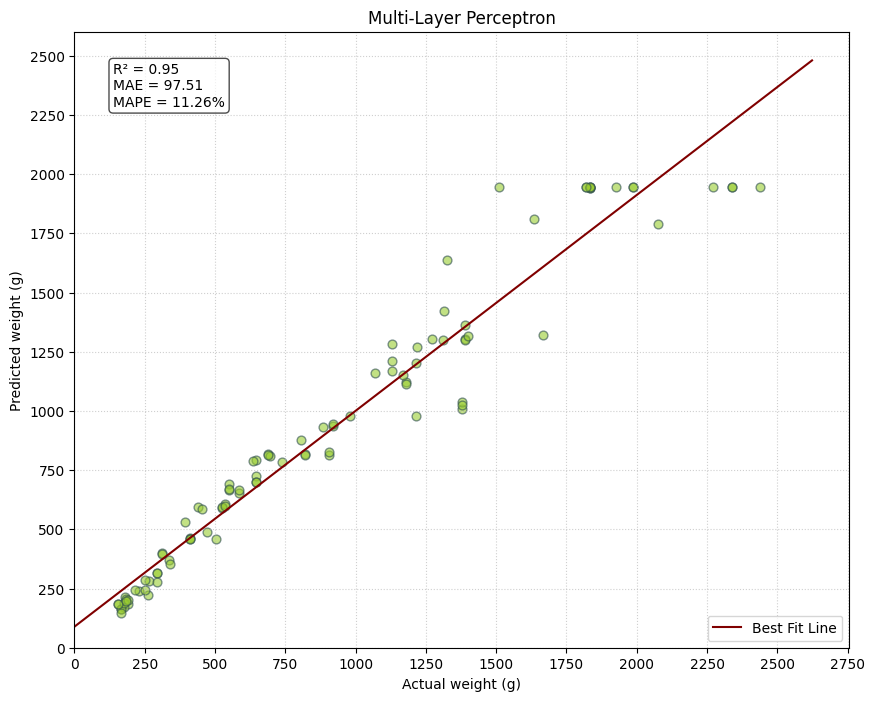

In [ ]:
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import numpy as np
import matplotlib.pyplot as plt

# X = df_final["pixel_area"].values
# y = df_final["Actual_Weight"].values

# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.3, random_state=25
# )

# Scaling
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train.reshape(-1, 1))
# X_test_scaled = scaler.transform(X_test.reshape(-1, 1))

# mlp = MLPRegressor(
#     hidden_layer_sizes=(128, 64, 32),
#     activation='relu',
#     solver='adam',
#     learning_rate_init=0.001,
#     max_iter=1000,
#     early_stopping=True,
#     validation_fraction=0.1,
#     n_iter_no_change=20,
#     random_state=25
# )

# mlp.fit(X_train_scaled, y_train)

# y_pred = mlp.predict(X_test_scaled)

# GRID SEARCH VERSION
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model",  MLPRegressor(
        max_iter=1000,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=20,
        random_state=25
    ))
])

param_grid = {
    "model__hidden_layer_sizes": [(64,), (128,), (128, 64), (128, 64, 32), (256, 128, 64)],
    "model__activation":         ["relu", "tanh"],
    "model__solver":             ["adam", "sgd"],
    "model__learning_rate_init": [0.001, 0.01, 0.005],
}

grid_search = GridSearchCV(
    estimator  = pipeline,
    param_grid = param_grid,
    scoring    = "neg_mean_absolute_percentage_error",
    cv         = 5,
    n_jobs     = -1,
    verbose    = 1
)

grid_search.fit(X_train.reshape(-1, 1), y_train)

print("Best params:", grid_search.best_params_)
print("Best CV MAPE:", -grid_search.best_score_ * 100, "%")

best_mlp = grid_search.best_estimator_
y_pred = best_mlp.predict(X_test.reshape(-1, 1))

# Metrics
r2   = r2_score(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = mean_absolute_percentage_error(y_test, y_pred) * 100

print(f"R²   : {r2:.4f}")
print(f"MAE  : {mae:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"MAPE : {mape:.2f}%")


# Plot
fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(y_test, y_pred, alpha=0.6, edgecolors='darkslategray', facecolors='yellowgreen', s=40)

# Axis range
lo = min(y_test.min(), y_pred.min())
hi = max(y_test.max(), y_pred.max())
pad = (hi - lo) * 0.08

# Best fit line
m, b = np.polyfit(y_test, y_pred, 1)

x_fit = np.array([lo - pad, hi + pad])
y_fit = m * x_fit + b

ax.plot(
    x_fit,
    y_fit,
    color='maroon',
    linewidth=1.5,
    label = 'Best Fit Line'
)
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)
ax.set_xlabel('Actual weight (g)')
ax.set_ylabel('Predicted weight (g)')
ax.set_title('Multi-Layer Perceptron')
ax.text(0.05, 0.95, f'R² = {r2:.2f}\nMAE = {mae:.2f}\nMAPE = {mape:.2f}%',
        transform=ax.transAxes, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
ax.grid(True, linestyle=':', alpha=0.6)
ax.xaxis.set_major_locator(ticker.MultipleLocator(250))
ax.yaxis.set_major_locator(ticker.MultipleLocator(250))
ax.legend(loc='lower right')
plt.show()